In [34]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr
from scipy.spatial.distance import euclidean, cdist

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from skimage.filters import gaussian, median

/tmp/ipykernel_789939/4157130849.py:33: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [35]:
# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 12
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), np.median(variance))
camera_parameters["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
camera_parameters["rqe"] = np.full((image_size, image_size), np.median(rqe))
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [36]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [37]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
nilered_filter = "semrock-ff01-650-200-25"
shortpass_filter = "semrock-bsp01-785r"
dichroic_nored_mirror = "semrock-di03-r488-561-t1-25x36"
lp_561 = "semrock-blp02-561r"
#bp_584 = "semrock-ff01-582-64"

filters = [notch_filter, dichroic_mirror, shortpass_filter]
filter_spectra = S_F.get_dye_or_filter_data(
    names=filters, wavelength=wavelength, dye_or_filter=False
)

In [38]:
filter_spectra

array([[  2.16939995e-07,   1.03219998e-06,   3.95419988e-07, ...,
          9.68299985e-01,   9.67199981e-01,   9.65170026e-01],
       [  4.39730007e-04,   2.44889990e-04,   3.83879989e-04, ...,
          9.47719991e-01,   9.46810007e-01,   9.45519984e-01],
       [  9.71580029e-01,   9.70969975e-01,   9.74910021e-01, ...,
          1.15539997e-05,   1.21100002e-05,   1.30369999e-05]])

In [39]:
S_F.get_pixel_fractions_dye_and_filters(filters=filters, dyes=['ATTO 488', 'ATTO 594'], pixel_QYs=pixel_QYs, wavelength=wavelength)

(array([ 532.99830455,  650.43650619]),
 array([[ 0.15561533,  0.74381804,  0.10056663],
        [ 0.04150118,  0.26898237,  0.68951644]]))

In [40]:
sigma = 1e-9
varepsilon = (sigma*6.023e23)/(np.log(10)*1e3)

In [41]:
varepsilon/1e11

2.6157556645032858

In [42]:
single_molecule_dyes = np.array(
    [
        ["ATTO 488", 2073],
        ["Alexa Fluor 488", 2811],
        ["CF488A", 3879],
        #["ATTO 594", 2000],
        ["Cy3B", 23195],
        ["ATTO 565", 11600],
        ["Janelia Fluor JF585-HaloTag conjugate", 2429],
        ["CF568", 13388],
        ["Cy5", 7801],
        ["Cy5B", 17090],
        ["ATTO 643", 23327],
        ["ATTO 647N", 18448],
        ["ATTO 655", 8273],
        ["CF640R", 12024],
        ["CF660R", 10399],
        ["abberior STAR 635", 12731],
        ["Janelia Fluor JF646-HaloTag conjugate", 14440],
        ["Alexa Fluor 647", 10348],
        ["Cy2", 6241],
        ["Cy3", 11022],
        ["Tetramethylrhodamine (TAMRA, TRITC)", 4884],
        ["Cy3.5", 4968],
        ["ATTO 647", 1526],
        ["ATTO 680", 1656],
        ["Cy5.5", 6337],
        ["Cy7", 852],
        ["Alexa Fluor 750", 703],
        ["ATTO 740", 779],
        ["Alexa Fluor 790", 740],
    ],
    dtype="object",
)

In [43]:
potential_dyes = [
    "Cy3B",
    #"ATTO 594",
    "CF550R",
    "Cy5B",
    "Alexa Fluor 488",
    "ATTO 488",
    "ATTO 643",
    "ATTO 647N",
    "ATTO 655",
    "Alexa Fluor 647",
    "CF640R",
    "CF660R",
    "abberior STAR 635",
    "ATTO 620",
    "ATTO 565",
    "CF568",
    "Janelia Fluor JF646-HaloTag conjugate",
    "ATTO 680",
    
]

In [44]:
import numpy as np
from src import Multicolour_Simulation_Functions
from src import SpectralFunctions


notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
nilered_filter = "semrock-ff01-650-200-25"
shortpass_filter = "semrock-bsp01-785r"
dichroic_nored_mirror = "semrock-di03-r488-561-t1-25x36"
lp_561 = "semrock-blp02-561r"
#bp_584 = "semrock-ff01-582-64"

filters = [notch_filter, dichroic_mirror, shortpass_filter]

# Select optimal 5 dyes
result = MSF.optimal_dye_selector_simulated(
    potential_dyes=potential_dyes,
    single_molecule_dyes=single_molecule_dyes,
    filters=filters,
    smoothing_function=smoothing_function,
    camera_parameters=camera_parameters,
    wavelength=wavelength,
    n_dyes_desired=5,
    min_photons_per_100ms=500,
    n_simulations=10000,
    exhaustive_search=True,  # Use greedy for speed
    background_photons=50,
    verbose=True,
    return_all_simulations=True
)

print(f"\nOptimal dyes: {result['selected_dyes']}")
print(f"Classification accuracy: {result['overall_accuracy']:.1%}")


OPTIMAL DYE SELECTION VIA SIMULATION

Step 1: Filtering dyes (min 500 photons/100ms)...


  17 candidates -> 14 viable dyes
  Rejected: {'ATTO 680', 'ATTO 620', 'CF550R'}

Step 2-3: Simulating 10000 molecules per dye...
  Simulating Cy3B (23195 source / 4878 detector photons)...
    Fit success: 10000/10000 (100.0%)                                           ?, ?it/s]
    Mean (A_R, A_G): (0.555, 0.414)
    Std  (A_R, A_G): (0.008, 0.008)
  Simulating Cy5B (17090 source / 3594 detector photons)...
    Fit success: 10000/10000 (100.0%)                                           ?, ?it/s]
    Mean (A_R, A_G): (0.711, 0.222)
    Std  (A_R, A_G): (0.009, 0.008)
  Simulating Alexa Fluor 488 (2811 source / 591 detector photons)...
    Fit success: 10000/10000 (100.0%)                                           ?, ?it/s]
    Mean (A_R, A_G): (0.089, 0.746)
    Std  (A_R, A_G): (0.019, 0.026)
  Simulating ATTO 488 (2073 source / 436 detector photons)...
    Fit success: 10000/10000 (100.0%)                                           ?, ?it/s]
    Mean (A_R, A_G): (0.100, 0.745)
    Std

# Plot 1: Exemplar ternary plots from each selected dye

---

## Visualization Methods: Scatter vs KDE Contours

This notebook uses **Kernel Density Estimate (KDE) contours** for ternary plots to accurately visualize dye separability. This addresses the "alpha transparency deception" issue where traditional scatter plots with transparency visually exaggerate overlap.

### Why KDE Contours?

**Problem with scatter plots:**
- Alpha blending creates visual "solid" regions where points overlap
- Human vision integrates overlapping transparent points, creating false perception
- Makes well-separated dyes (99% accuracy) appear poorly separated

**Solution with KDE contours:**
- Shows true 2D probability density without visual artifacts
- Clean contour lines don't create deceptive overlaps
- Visual appearance matches actual classification performance
- Publication-quality figures that accurately represent separability

### Understanding Confidence Levels

KDE contours show probability density regions:

- **50% contour** (thickest line): Core region containing 50% of probability mass  
  *This is where most molecules will appear*

- **90% contour** (medium line): Extended region containing 90% of probability mass  
  *Captures the bulk of the distribution*

- **99% contour** (thinnest line): Outer tail containing 99% of probability mass  
  *Shows the full extent including rare outliers*

**Key insight:** If contours don't overlap, dyes are well separated even if scatter plots look messy!

---

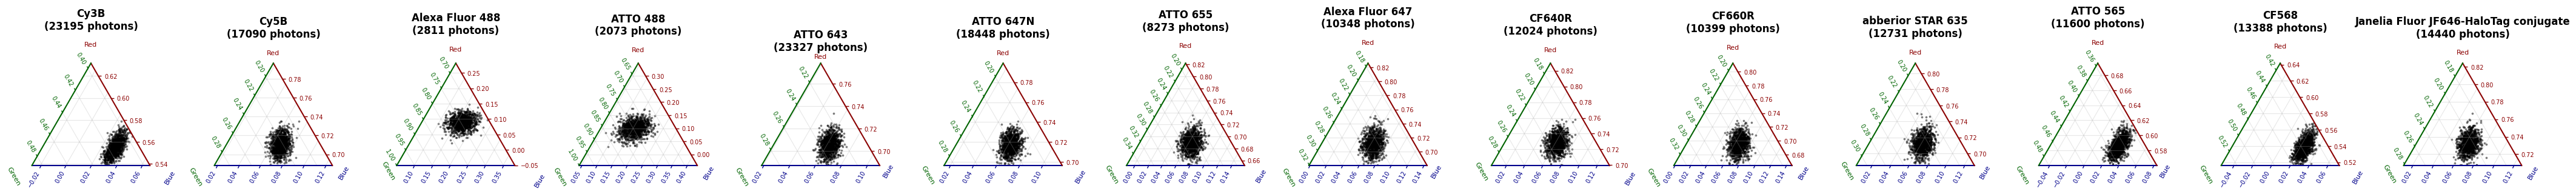

In [29]:
# Plot 1: Exemplar ternary plots from each selected dye
from PlottingBase import PublicationPlotter

pub_plotter = PublicationPlotter()
n_dyes = len(result["viable_dyes"])

fig = plt.figure(figsize=(3*n_dyes, 4.5))

for i, dye_name in enumerate(result["viable_dyes"]):
    # Get simulation data for this dye
    sim_data = result["dye_simulations"][dye_name]
    A_R = sim_data["A_R"]
    A_G = sim_data["A_G"]
    A_B = sim_data["A_B"]
    
    # Remove NaN values
    valid = ~(np.isnan(A_R) | np.isnan(A_G) | np.isnan(A_B))
    A_R = A_R[valid]
    A_G = A_G[valid]
    A_B = A_B[valid]
    
    # Plot first 1000 examples on ternary plot
    n_plot = min(1000, len(A_R))
    
    ax = fig.add_subplot(1, n_dyes, i+1, projection="ternary")
    
    # Scatter plot
    ax.scatter(A_R[:n_plot], A_G[:n_plot], A_B[:n_plot], 
              s=3, alpha=0.4, c="black", rasterized=True)
    
    # Calculate zoom limits using set_ternary_min and set_ternary_max
    # These methods automatically maintain the triangular constraint
    # For ternary plots: t (top) = R, l (left) = G, r (right) = B
    
    mean_R, std_R = A_R.mean(), A_R.std()
    mean_G, std_G = A_G.mean(), A_G.std()
    mean_B, std_B = A_B.mean(), A_B.std()
    
    # Calculate desired ranges
    margin_factor = 10.0
    R_min = max(0.0, mean_R - margin_factor * std_R)
    R_max = min(1.0, mean_R + margin_factor * std_R)
    G_min = max(0.0, mean_G - margin_factor * std_G)
    G_max = min(1.0, mean_G + margin_factor * std_G)
    B_min = max(0.0, mean_B - margin_factor * std_B)
    B_max = min(1.0, mean_B + margin_factor * std_B)
    
    # Use set_ternary_min and set_ternary_max which automatically
    # adjust limits to maintain triangular shape
    ax.set_ternary_min(R_min, G_min, B_min)
    ax.set_ternary_max(R_max, G_max, B_max)
    
    # Set labels with colors
    ax.set_tlabel("Red", color="darkred", fontsize=8)
    ax.set_llabel("Green", color="darkgreen", fontsize=8)
    ax.set_rlabel("Blue", color="darkblue", fontsize=8)
    
    # Color axis lines
    ax.spines["lside"].set_color("darkred")
    ax.spines["rside"].set_color("darkgreen")
    ax.spines["tside"].set_color("darkblue")
    ax.spines["lside"].set_linewidth(1.5)
    ax.spines["rside"].set_linewidth(1.5)
    ax.spines["tside"].set_linewidth(1.5)
    
    # Tick parameters
    ax.taxis.set_tick_params(colors="darkred", labelsize=7)
    ax.laxis.set_tick_params(colors="darkgreen", labelsize=7)
    ax.raxis.set_tick_params(colors="darkblue", labelsize=7)
    
    # Grid
    ax.grid(True, alpha=0.3)
    
    # Title
    ax.set_title(f"{dye_name}\n({result["expected_photons"][dye_name]:.0f} photons)",
                fontsize=12, fontweight="bold", pad=15)

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20251120/fig/multicolour/Dye_Mixtures/'
plt.tight_layout()
plt.savefig(os.path.join(folder, 'Exemplar_Simulation_ndyes.svg'), dpi=600, format='svg')
plt.show()


# Plot 2: Ternary density plot of ALL localisations from all viable dyes

Total localizations to plot: 140,000


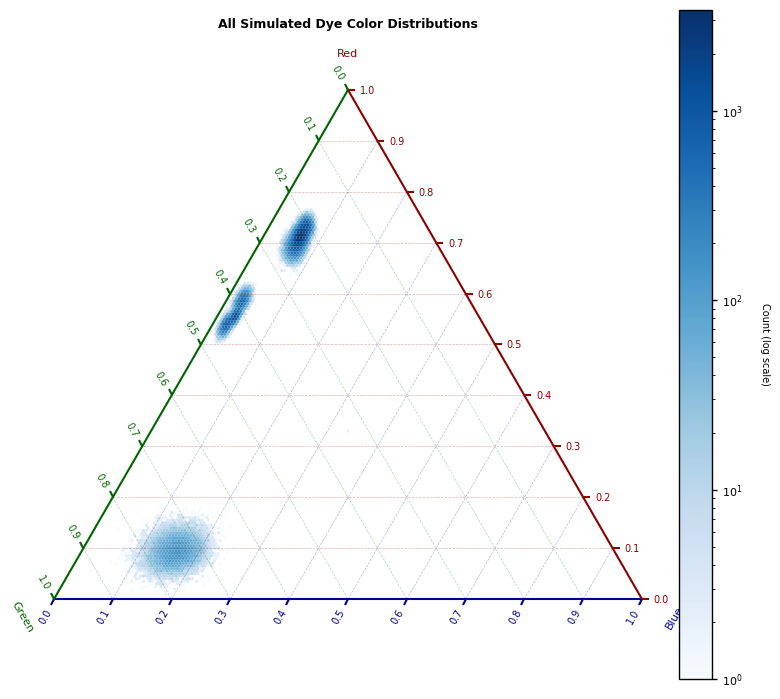

In [30]:
# Plot 2: Ternary density plot of ALL localisations from all viable dyes
from PlottingBase import PublicationPlotter

pub_plotter = PublicationPlotter()

# Collect all simulation data
all_A_R = []
all_A_G = []
all_A_B = []

for dye_name in result["dye_simulations"].keys():
    print(dye_name)
    sim_data = result["dye_simulations"][dye_name]
    # Remove NaN values
    valid = ~(np.isnan(sim_data["A_R"]) | np.isnan(sim_data["A_G"]) | np.isnan(sim_data["A_B"]))
    all_A_R.extend(sim_data["A_R"][valid])
    all_A_G.extend(sim_data["A_G"][valid])
    all_A_B.extend(sim_data["A_B"][valid])

all_A_R = np.array(all_A_R)
all_A_G = np.array(all_A_G)
all_A_B = np.array(all_A_B)

print(f"Total localisations to plot: {len(all_A_R):,}")

# Use ternary density plot (hexbin)
fig, ax = pub_plotter.create_ternary_density(
    all_A_R, all_A_G, all_A_B,
    gridsize=200,
    cmap="Blues",
    title="All Simulated Dye Color Distributions",
    figsize=(8, 7),
    log_scale=True,
    show_colorbar=True
)

# Adjust font sizes
ax.set_tlabel("Red", color="darkred", fontsize=8)
ax.set_llabel("Green", color="darkgreen", fontsize=8)
ax.set_rlabel("Blue", color="darkblue", fontsize=8)
ax.taxis.set_tick_params(labelsize=7)
ax.laxis.set_tick_params(labelsize=7)
ax.raxis.set_tick_params(labelsize=7)
ax.set_title("All Simulated Dye Color Distributions", fontsize=9, fontweight="bold", pad=15)

plt.tight_layout()
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20251120/fig/multicolour/Dye_Mixtures/'
plt.tight_layout()
plt.savefig(os.path.join(folder, 'All_dye_simulation.svg'), dpi=600, format='svg')

plt.show()


# Plot 3: Top combinations displayed on ternary plots

In [ ]:
# Plot 3: Top combinations displayed on ternary plots (with KDE contours)
if result["all_combinations_tested"] is not None:
    # Exhaustive search mode - show top 10 combinations
    combos = result["all_combinations_tested"][:10]
    
    fig = plt.figure(figsize=(20, 8))
    
    for i, combo_result in enumerate(combos):
        combo_dyes = combo_result["dyes"]
        accuracy = combo_result["accuracy"]
        
        ax = fig.add_subplot(2, 5, i+1, projection="ternary")
        
        # Plot all dyes faintly in background (optional - can be removed for cleaner look)
        for dye_name in result["dye_simulations"].keys():
            sim_data = result["dye_simulations"][dye_name]
            valid = ~(np.isnan(sim_data["A_R"]) | np.isnan(sim_data["A_G"]) | np.isnan(sim_data["A_B"]))
            n_plot = min(500, valid.sum())
            indices = np.random.choice(np.where(valid)[0], n_plot, replace=False)
            ax.scatter(sim_data["A_R"][indices], sim_data["A_G"][indices], sim_data["A_B"][indices],
                      s=0.5, alpha=0.03, c="gray", rasterized=True)
        
        # Plot KDE contours for selected combination
        colors = plt.cm.tab10(range(len(combo_dyes)))
        for j, dye_name in enumerate(combo_dyes):
            if dye_name in result["dye_simulations"]:
                sim_data = result["dye_simulations"][dye_name]
                valid = ~(np.isnan(sim_data["A_R"]) | np.isnan(sim_data["A_G"]) | np.isnan(sim_data["A_B"]))
                
                # Plot KDE contours showing 50% and 90% confidence regions
                from matplotlib.colors import to_hex
                color_hex = to_hex(colors[j])
                pub_plotter.plot_ternary_kde_contours(
                    ax, 
                    sim_data["A_R"][valid], 
                    sim_data["A_G"][valid], 
                    sim_data["A_B"][valid],
                    color=color_hex,
                    label=None,  # No legend for individual plots
                    levels=[0.5, 0.9],  # 50% and 90% confidence
                    linewidths=[2, 1],  # Thicker for 50%, thinner for 90%
                    bandwidth='scott'
                )
        
        # Styling
        ax.set_tlabel("", color="darkred", fontsize=8)
        ax.set_llabel("", color="darkgreen", fontsize=8)
        ax.set_rlabel("", color="darkblue", fontsize=8)
        ax.taxis.set_tick_params(labelsize=7)
        ax.laxis.set_tick_params(labelsize=7)
        ax.raxis.set_tick_params(labelsize=7)
        
        # Color spines
        ax.spines["lside"].set_color("darkred")
        ax.spines["rside"].set_color("darkgreen")
        ax.spines["tside"].set_color("darkblue")
        
        ax.grid(True, alpha=0.2)
        
        rank_str = "BEST" if i == 0 else f"#{i+1}"
        ax.set_title(f"{rank_str}: {accuracy:.1%}",
                    fontsize=12, fontweight="bold" if i == 0 else "normal", pad=10)
    
    plt.suptitle("Top 10 Dye Combinations (KDE Contours: 50%, 90%)", 
                fontsize=14, fontweight="bold", y=0.98)
    folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20251120/fig/multicolour/Dye_Mixtures/'
    plt.tight_layout()
    plt.savefig(os.path.join(folder, 'Top_10_dye_combinations_kde.svg'), dpi=600, format='svg')
    plt.show()
else:
    print("Greedy search mode - no combination history available")
    print("Rerun with exhaustive_search=True to visualize all tested combinations")


# Plot 4: Optimal dye selection displayed on ternary plot

In [ ]:
# Plot 4: Optimal dye selection displayed on ternary plot (with KDE contours)
from PlottingBase import PublicationPlotter

pub_plotter = PublicationPlotter()
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="ternary")

selected_dyes = result["selected_dyes"]
colors = plt.cm.tab10(range(len(selected_dyes)))

# Plot each selected dye
for i, dye_name in enumerate(selected_dyes):
    sim_data = result["dye_simulations"][dye_name]
    
    # Remove NaN values
    valid = ~(np.isnan(sim_data["A_R"]) | np.isnan(sim_data["A_G"]) | np.isnan(sim_data["A_B"]))
    A_R = sim_data["A_R"][valid]
    A_G = sim_data["A_G"][valid]
    A_B = sim_data["A_B"][valid]
    
    # Plot simulation points (lighter, smaller)
    n_plot = min(500, len(A_R))
    ax.scatter(A_R[:n_plot], A_G[:n_plot], A_B[:n_plot],
              s=3, alpha=0.15, c=[colors[i]], rasterized=True)
    
    # Plot KDE contours showing 50%, 90%, 99% confidence regions
    from matplotlib.colors import to_hex
    color_hex = to_hex(colors[i])
    pub_plotter.plot_ternary_kde_contours(
        ax, A_R, A_G, A_B,
        color=color_hex,
        label=dye_name,
        levels=[0.5, 0.9, 0.99],  # 50%, 90%, and 99% confidence
        linewidths=[3, 2, 1],  # Thicker for core, thinner for tail
        bandwidth='scott',
        alpha=0.9
    )
    
    # Annotate with dye number at mean position
    mean_R, mean_G, mean_B = A_R.mean(), A_G.mean(), A_B.mean()
    ax.text(mean_R, mean_G, mean_B, str(i+1), fontsize=10, fontweight="bold",
           ha="center", va="center", color="white",
           bbox=dict(boxstyle="circle", facecolor=colors[i], edgecolor="white", linewidth=2))

# Set labels with colors
ax.set_tlabel("Red", color="darkred", fontsize=8)
ax.set_llabel("Green", color="darkgreen", fontsize=8)
ax.set_rlabel("Blue", color="darkblue", fontsize=8)

# Color axis lines
ax.spines["lside"].set_color("darkred")
ax.spines["rside"].set_color("darkgreen")
ax.spines["tside"].set_color("darkblue")
ax.spines["lside"].set_linewidth(1.5)
ax.spines["rside"].set_linewidth(1.5)
ax.spines["tside"].set_linewidth(1.5)

# Tick parameters
ax.taxis.set_tick_params(colors="darkred", labelsize=7)
ax.laxis.set_tick_params(colors="darkgreen", labelsize=7)
ax.raxis.set_tick_params(colors="darkblue", labelsize=7)

# Grid
ax.grid(True, alpha=0.3)

# Title and legend
ax.set_title(f"Optimal {len(selected_dyes)}-Dye Combination (KDE Contours)\n"
            f"Overall Accuracy: {result["overall_accuracy"]:.1%}",
            fontsize=12, fontweight="bold", pad=15)

# Use the KDE legend handles if available
if hasattr(ax, '_kde_legend_handles'):
    ax.legend(handles=ax._kde_legend_handles, fontsize=8, loc=(1.05, 0.3), framealpha=0.9,
             title="Confidence: 50%, 90%, 99%", title_fontsize=7)
else:
    ax.legend(fontsize=8, loc=(1.05, 0.5), framealpha=0.9)

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20251120/fig/multicolour/Dye_Mixtures/'
plt.tight_layout()
plt.savefig(os.path.join(folder, 'Optimal_dye_selection_kde.svg'), dpi=600, format='svg')
plt.show()


# Plot 5: Classification accuracy determination

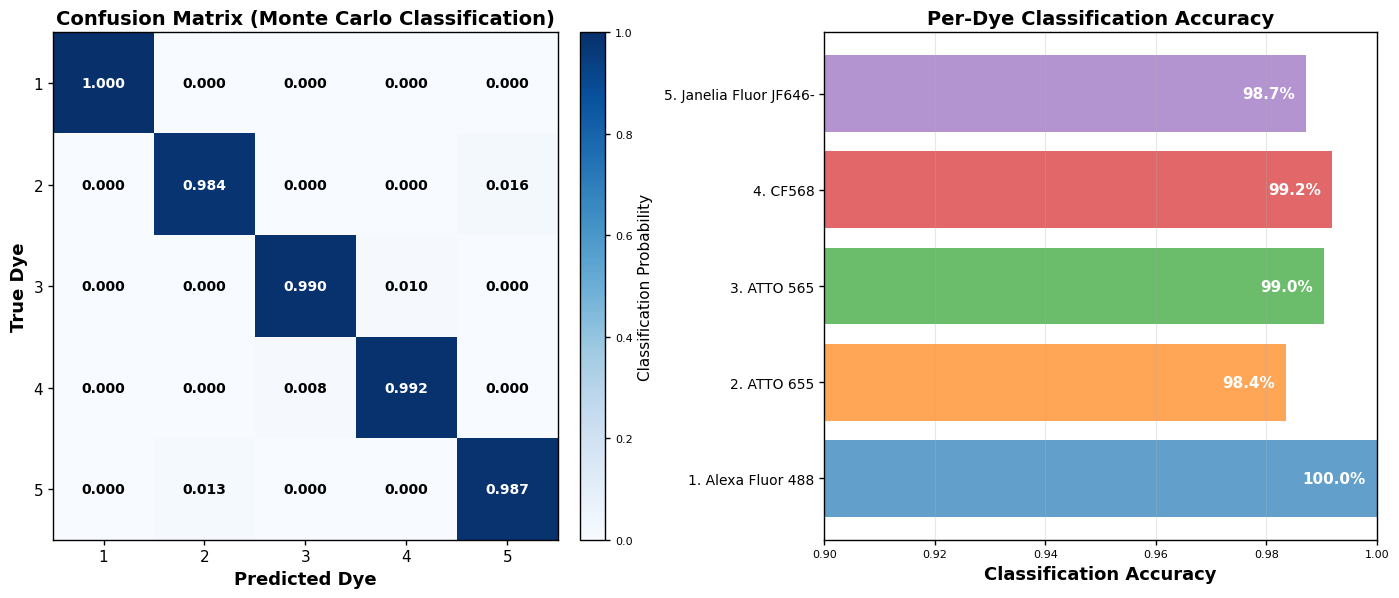

CLASSIFICATION ACCURACY SUMMARY
1. Alexa Fluor 488                         : 100.00%
2. ATTO 655                                : 98.36%
3. ATTO 565                                : 99.04%
4. CF568                                   : 99.19%
5. Janelia Fluor JF646-HaloTag conjugate   : 98.72%
Overall accuracy: 99.06%


In [55]:
# Plot 5: Classification accuracy determination
from PlottingBase import PublicationPlotter

pub_plotter = PublicationPlotter()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Confusion Matrix
ax = axes[0]
confusion = result["confusion_matrix"]
selected_dyes = result["selected_dyes"]

im = ax.imshow(confusion, cmap="Blues", vmin=0, vmax=1, aspect="auto")

# Add text annotations
for i in range(len(selected_dyes)):
    for j in range(len(selected_dyes)):
        value = confusion[i, j]
        color = "white" if value > 0.5 else "black"
        ax.text(j, i, f"{value:.3f}", ha="center", va="center",
               fontsize=10, fontweight="bold", color=color)

ax.set_xticks(range(len(selected_dyes)))
ax.set_yticks(range(len(selected_dyes)))
ax.set_xticklabels([f"{i+1}" for i in range(len(selected_dyes))], fontsize=11)
ax.set_yticklabels([f"{i+1}" for i in range(len(selected_dyes))], fontsize=11)
ax.set_xlabel("Predicted Dye", fontsize=13, fontweight="bold")
ax.set_ylabel("True Dye", fontsize=13, fontweight="bold")
ax.set_title("Confusion Matrix (Monte Carlo Classification)", 
            fontsize=14, fontweight="bold")

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Classification Probability", fontsize=11)

# Panel B: Per-Dye Accuracy
ax = axes[1]
per_dye_accuracy = np.diag(confusion)
dye_labels = [f"{i+1}. {dye[:20]}" for i, dye in enumerate(selected_dyes)]

bars = ax.barh(range(len(selected_dyes)), per_dye_accuracy, 
              color=plt.cm.tab10(range(len(selected_dyes))), alpha=0.7)
ax.set_yticks(range(len(selected_dyes)))
ax.set_yticklabels(dye_labels, fontsize=10)
ax.set_xlabel("Classification Accuracy", fontsize=13, fontweight="bold")
ax.set_title("Per-Dye Classification Accuracy", fontsize=14, fontweight="bold")
ax.set_xlim(0.9, 1.0)
ax.grid(True, alpha=0.3, axis="x")

# Add value labels
for i, (bar, acc) in enumerate(zip(bars, per_dye_accuracy)):
    ax.text(acc - 0.002, bar.get_y() + bar.get_height()/2, 
           f"{acc:.1%}", ha="right", va="center", 
           fontsize=11, fontweight="bold", color="white")

plt.tight_layout()
plt.savefig(os.path.join(folder, 'Confusion_Matrices.svg'), dpi=600, format='svg')
plt.show()

# Print summary statistics
print("" + "="*60)
print("CLASSIFICATION ACCURACY SUMMARY")
print("="*60)
for i, dye in enumerate(selected_dyes):
    acc = per_dye_accuracy[i]
    print(f"{i+1}. {dye:40s}: {acc:.2%}")
print(f"Overall accuracy: {result["overall_accuracy"]:.2%}")
print("="*60)


# Plot 6: Scatter vs KDE Comparison

This plot demonstrates the "alpha transparency deception" issue with scatter plots. The same data is shown two ways:

**Left panel (Scatter)**: Traditional scatter plot with alpha transparency creates visual overlap that exaggerates poor separability  
**Right panel (KDE Contours)**: Kernel density estimate contours show the true statistical separability

**Key insight**: Despite the scatter plot making it look like dyes heavily overlap, the KDE contours reveal clean separation that matches the 99.1% classification accuracy from the confusion matrix.

**Confidence levels**:
- **50% contour** (thickest line): Core region containing 50% of probability mass
- **90% contour** (medium line): Extended region containing 90% of probability mass  
- **99% contour** (thinnest line): Outer tail containing 99% of probability mass

In [ ]:
# Plot 6: Comparison - Scatter vs KDE Contours
from PlottingBase import PublicationPlotter

pub_plotter = PublicationPlotter()
fig = plt.figure(figsize=(18, 8))

selected_dyes = result["selected_dyes"]
colors = plt.cm.tab10(range(len(selected_dyes)))

# Left panel: Traditional scatter plot
ax_scatter = fig.add_subplot(1, 2, 1, projection="ternary")

for i, dye_name in enumerate(selected_dyes):
    sim_data = result["dye_simulations"][dye_name]
    
    # Remove NaN values
    valid = ~(np.isnan(sim_data["A_R"]) | np.isnan(sim_data["A_G"]) | np.isnan(sim_data["A_B"]))
    A_R = sim_data["A_R"][valid]
    A_G = sim_data["A_G"][valid]
    A_B = sim_data["A_B"][valid]
    
    # Plot all points with alpha transparency (traditional approach)
    n_plot = min(2000, len(A_R))
    ax_scatter.scatter(A_R[:n_plot], A_G[:n_plot], A_B[:n_plot],
                      s=8, alpha=0.4, c=[colors[i]], label=f"{i+1}. {dye_name[:15]}", 
                      rasterized=True)

# Styling for scatter plot
ax_scatter.set_tlabel("Red", color="darkred", fontsize=10)
ax_scatter.set_llabel("Green", color="darkgreen", fontsize=10)
ax_scatter.set_rlabel("Blue", color="darkblue", fontsize=10)
ax_scatter.spines["lside"].set_color("darkred")
ax_scatter.spines["rside"].set_color("darkgreen")
ax_scatter.spines["tside"].set_color("darkblue")
ax_scatter.spines["lside"].set_linewidth(1.5)
ax_scatter.spines["rside"].set_linewidth(1.5)
ax_scatter.spines["tside"].set_linewidth(1.5)
ax_scatter.taxis.set_tick_params(colors="darkred", labelsize=8)
ax_scatter.laxis.set_tick_params(colors="darkgreen", labelsize=8)
ax_scatter.raxis.set_tick_params(colors="darkblue", labelsize=8)
ax_scatter.grid(True, alpha=0.3)
ax_scatter.set_title("A. Traditional Scatter Plot\n(Alpha blending creates deceptive overlap)",
                    fontsize=13, fontweight="bold", pad=15)
ax_scatter.legend(fontsize=7, loc="upper right", framealpha=0.9)

# Right panel: KDE contours
ax_kde = fig.add_subplot(1, 2, 2, projection="ternary")

for i, dye_name in enumerate(selected_dyes):
    sim_data = result["dye_simulations"][dye_name]
    
    # Remove NaN values
    valid = ~(np.isnan(sim_data["A_R"]) | np.isnan(sim_data["A_G"]) | np.isnan(sim_data["A_B"]))
    A_R = sim_data["A_R"][valid]
    A_G = sim_data["A_G"][valid]
    A_B = sim_data["A_B"][valid]
    
    # Plot a few scatter points for reference (very light)
    n_plot = min(300, len(A_R))
    ax_kde.scatter(A_R[:n_plot], A_G[:n_plot], A_B[:n_plot],
                  s=2, alpha=0.1, c=[colors[i]], rasterized=True)
    
    # Plot KDE contours
    from matplotlib.colors import to_hex
    color_hex = to_hex(colors[i])
    pub_plotter.plot_ternary_kde_contours(
        ax_kde, A_R, A_G, A_B,
        color=color_hex,
        label=f"{i+1}. {dye_name[:15]}",
        levels=[0.5, 0.9, 0.99],  # 50%, 90%, 99% confidence
        linewidths=[3, 2, 1],  # Thicker for core, thinner for tail
        bandwidth='scott',
        alpha=0.9
    )

# Styling for KDE plot
ax_kde.set_tlabel("Red", color="darkred", fontsize=10)
ax_kde.set_llabel("Green", color="darkgreen", fontsize=10)
ax_kde.set_rlabel("Blue", color="darkblue", fontsize=10)
ax_kde.spines["lside"].set_color("darkred")
ax_kde.spines["rside"].set_color("darkgreen")
ax_kde.spines["tside"].set_color("darkblue")
ax_kde.spines["lside"].set_linewidth(1.5)
ax_kde.spines["rside"].set_linewidth(1.5)
ax_kde.spines["tside"].set_linewidth(1.5)
ax_kde.taxis.set_tick_params(colors="darkred", labelsize=8)
ax_kde.laxis.set_tick_params(colors="darkgreen", labelsize=8)
ax_kde.raxis.set_tick_params(colors="darkblue", labelsize=8)
ax_kde.grid(True, alpha=0.3)
ax_kde.set_title("B. KDE Contour Plot\n(Reveals true separability: 50%, 90%, 99%)",
                fontsize=13, fontweight="bold", pad=15)

# Use KDE legend handles if available
if hasattr(ax_kde, '_kde_legend_handles'):
    ax_kde.legend(handles=ax_kde._kde_legend_handles, fontsize=7, 
                 loc="upper right", framealpha=0.9)

plt.suptitle(f"Visual Deception in Dye Separability\n"
            f"Same Data, Different Visualization (Overall Accuracy: {result['overall_accuracy']:.1%})",
            fontsize=15, fontweight="bold", y=0.98)

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20251120/fig/multicolour/Dye_Mixtures/'
plt.tight_layout()
plt.savefig(os.path.join(folder, 'Scatter_vs_KDE_comparison.svg'), dpi=600, format='svg')
plt.show()
